# Preprocess .mat files
* version 1.1 CS 10
* data 20.10.2025
* author A.Subbotin

In [4]:
import scipy.io as sio  # Ensure scipy is imported for .mat file handling
import numpy as np  # Ensure numpy is imported for array handling
import pandas as pd  # Ensure pandas is imported for DataFrame handling
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

In [ ]:
def mat_to_pandas(mat_file_path, features_list):
    data = sio.loadmat(mat_file_path)

    # Extract the relevant data from the loaded .mat file
    insData = data['insData']
    extracted_data = {feature: insData[feature][0][0][0][0]['value'].T[0]  for feature in features_list}
    extracted_data['time'] = insData[features_list[0]][0][0][0][0]['time'].T[0]  # Extracting time separately    
    # Convert the extracted data to a pandas DataFrame
    df = pd.DataFrame.from_dict(extracted_data)

    return df

# Example usage
example_file_path = r"C:\Users\msbka\20140221_04_01_03_250lm.mat"

features = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']

features_filt = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCGFilt', 'ayCGFilt', 'yawRateFilt']
df = mat_to_pandas(example_file_path, features)

# Display the first few rows of the DataFrame
print(df.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


* vxCG                       longitudinal velocity of the vehicle body measured at the center of gravity in meters per second
* vyCG                       lateral velocity of the vehicle body measured at the center of gravity in meters per second

* axCG                       longitudinal acceleration of the vehicle body measured at the center of gravity in meters per second per second
* ayCG                       lateral acceleration of the vehicle body measured at the center of gravity in meters per second per second

* yawRate                    vehicle body-frame angular rate in the z-direction in degrees per second
* yawAngle                   yaw angle (heading) of the vehicle body in degrees

* sideSlip                   vehicle body side slip angle defined as the angle between the vehicle body heading and the vehicle body horizontal velocity vector in degrees

In [7]:
from datetime import timedelta

def save_to_file(data, file_name):
    """
    Save the DataFrame to a CSV file.
    
    Parameters:
    data (pd.DataFrame): The DataFrame to save.
    file_name (str): The name of the file to save the DataFrame to.
    """
    data.to_csv(file_name, index=False)
    print(f"Data saved to {file_name}")

def plot_data(dataset, start_t=1000, stop_t=2260):
    start_td = timedelta(seconds=int(start_t))
    stop_td = timedelta(seconds=int(stop_t))
    duration_td = timedelta(seconds=int(stop_t - start_t))

    print(f"Start time: {str(start_td)}")
    print(f"Stop time: {str(stop_td)}")
    print(f"Duration: {str(duration_td)}")
    
    
    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['vxCG'], label='Velocity X', color='blue')
    plt.plot(dataset['time'], dataset['vyCG'], label='Velocity Y', color='red')
    plt.vlines([start_t, stop_t], ymin=min(dataset['vxCG'].min(), dataset['vyCG'].min()),
           ymax=max(dataset['vxCG'].max(), dataset['vyCG'].max()),
           colors='green', linestyles='dashed', label='Interval')
    plt.ion()
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.title('Vehicle Velocities Over Time')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['sideSlip'], label='Side Slip', color='purple')
    plt.vlines([start_t, stop_t], ymin=dataset['sideSlip'].min(), ymax=dataset['sideSlip'].max(),
           colors='green', linestyles='dashed', label='Interval')
    plt.xlabel('Time (s)')
    plt.ylabel('Side Slip (grad)')
    plt.title('Vehicle Side Slip Over Time')
    plt.legend()
    plt.grid()
    plt.show()
    
def plot_vehicle_path(train_data):
    plt.figure(figsize=(10, 6))
    plt.scatter(train_data['latitude'], train_data['longitude'], c=train_data['sideSlip'].abs(), label='Vehicle Path', marker='.', s=1, edgecolors='none', cmap='coolwarm', alpha=0.5,
                norm=plt.Normalize(vmin=0, vmax=1))
    plt.colorbar(label='Side Slip')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.title('Vehicle Path Colored by Side Slip')
    plt.legend()
    plt.grid()
    plt.show()

___
# Test  data

In [8]:

test_file_path = r"C:\Users\msbka\20140221_04_01_03_250lm.mat"
test_data = mat_to_pandas(test_file_path, features)
# Display the first few rows of the test DataFrame
print(test_data.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


Start time: 0:00:50
Stop time: 0:12:20
Duration: 0:11:30


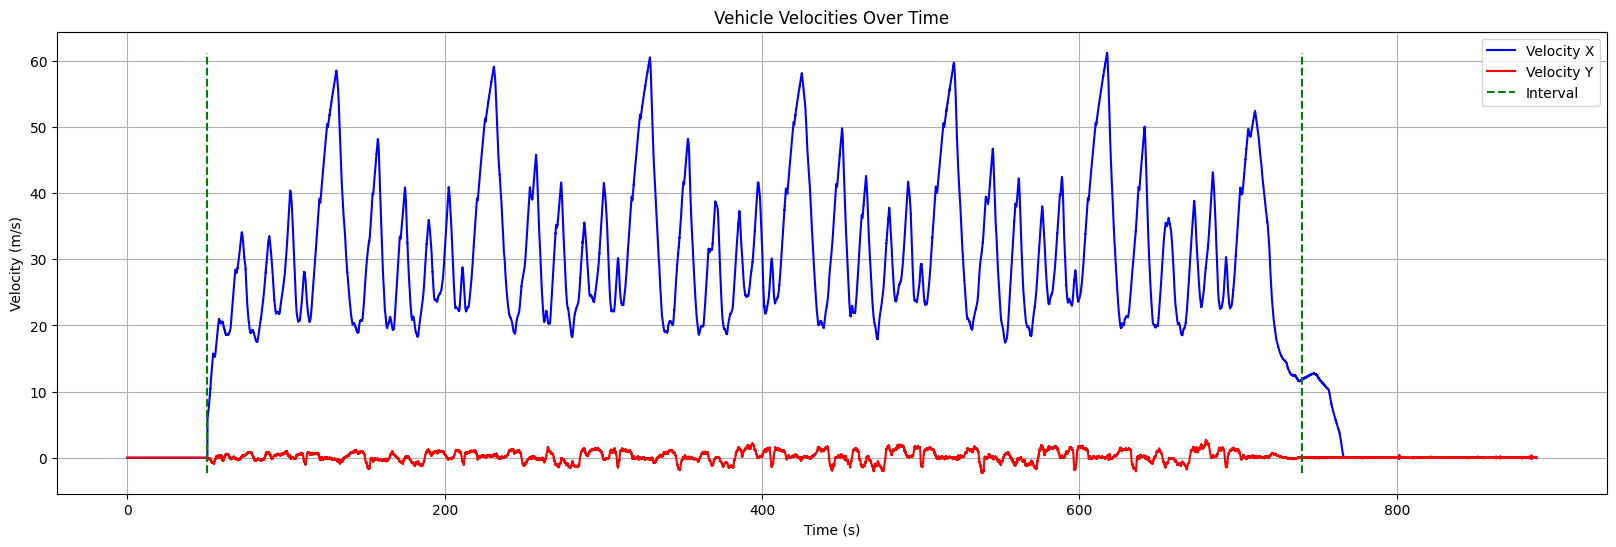

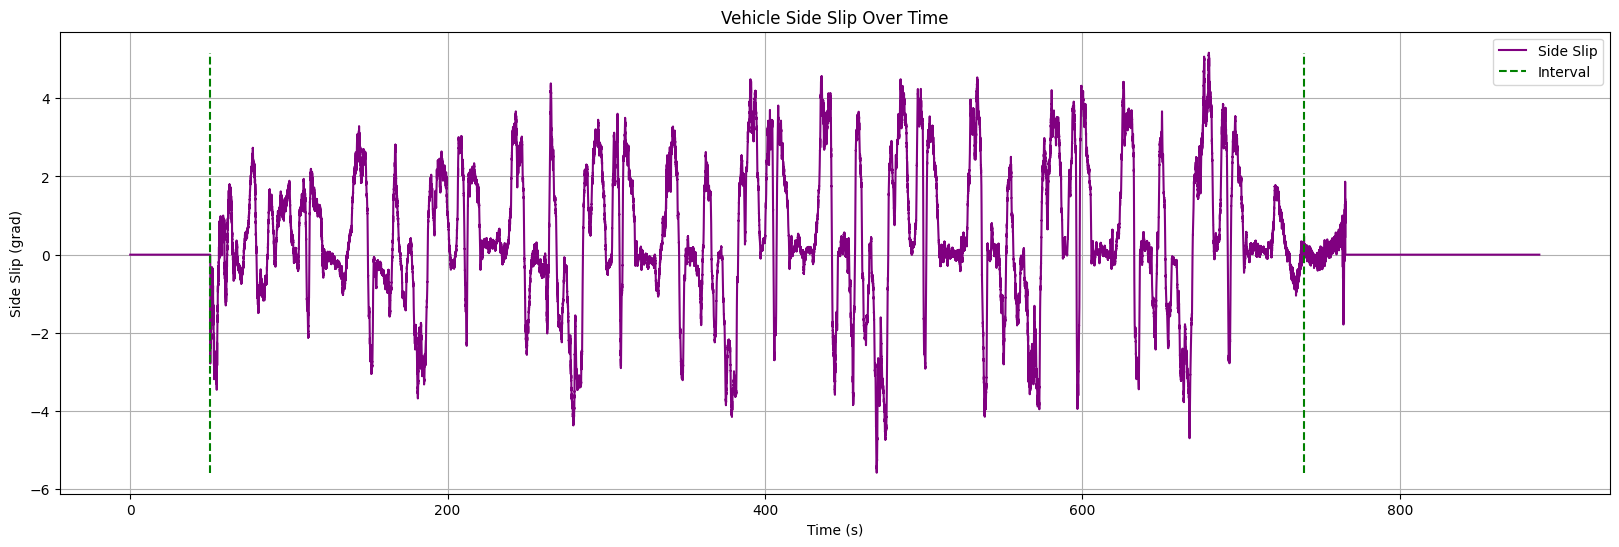

In [9]:
start_t=50
stop_t=start_t + 11.5*60
plot_data(test_data, start_t=start_t, stop_t=stop_t)

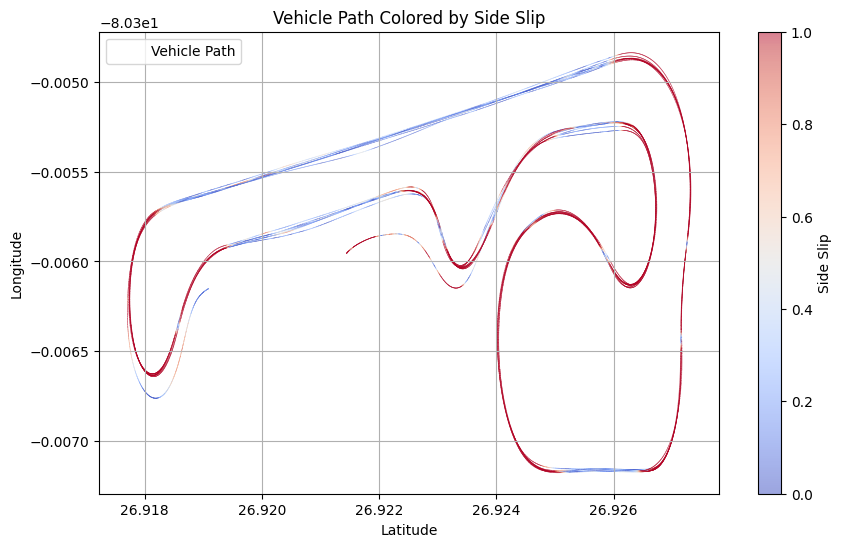

In [10]:
test_data = test_data[(test_data['time'] >= start_t) & (test_data['time'] <= stop_t)]

plot_vehicle_path(test_data)

In [11]:
save_to_file(test_data, 'processed_test_data.csv')

Data saved to processed_test_data.csv


# One Lap

___

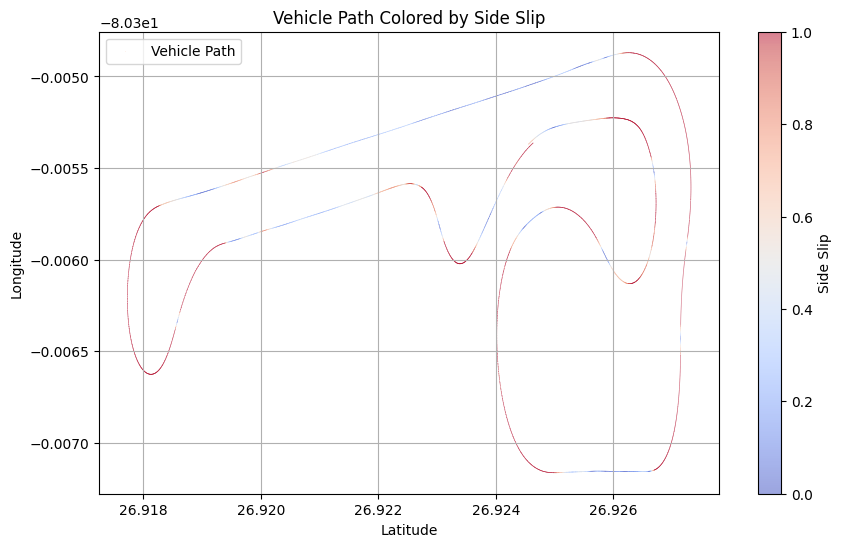

In [12]:
one_lap_data = test_data[(test_data['time'] >= 70) & (test_data['time'] <= 173)] #276
plot_vehicle_path(one_lap_data)

In [13]:
save_to_file(one_lap_data, 'processed_test_one_lap_data.csv')

Data saved to processed_test_one_lap_data.csv


# Train  data

In [14]:

train_file_path = r"C:\Users\msbka\Downloads\20130222_01_02_03_grandsport.mat"
train_data = mat_to_pandas(train_file_path, features)
# Display the first few rows of the test DataFrame
print(train_data.head())

    latitude  longitude  sideSlip      vxCG      vyCG      axCG      ayCG  \
0  26.920794 -80.306057       0.0 -0.008763  0.004499  0.215831  0.571743   
1  26.920794 -80.306057       0.0 -0.008364  0.012522  0.009553 -0.654905   
2  26.920794 -80.306057       0.0 -0.007207  0.019551 -0.088390 -0.241379   
3  26.920794 -80.306057       0.0 -0.009070 -0.000904  0.063293  0.049130   
4  26.920794 -80.306057       0.0 -0.008928 -0.009824 -0.000731 -0.062028   

    yawRate  time  
0 -0.064669  0.00  
1  0.041858  0.01  
2  0.076798  0.02  
3 -0.026415  0.03  
4  0.006813  0.04  


In [ ]:
#  Handle NaNs and Interpolate Missing Values

print(" NaN values before interpolation:\n")
print(train_data.isna().sum())

train_data.interpolate(method='linear', limit_direction='both', inplace=True)
train_data.fillna(0, inplace=True)

print("\n NaN values after interpolation and filling:\n")
print(train_data.isna().sum())


 NaN values before interpolation:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64

 NaN values after interpolation and filling:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64


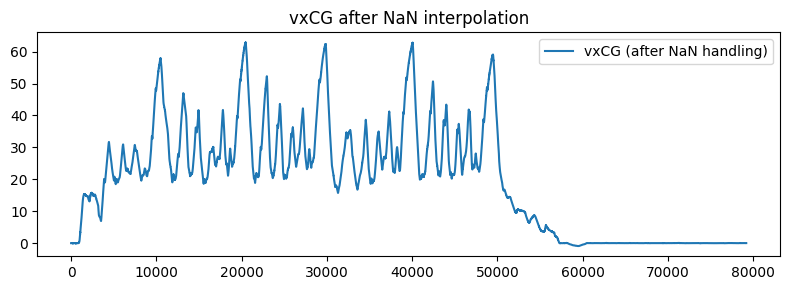

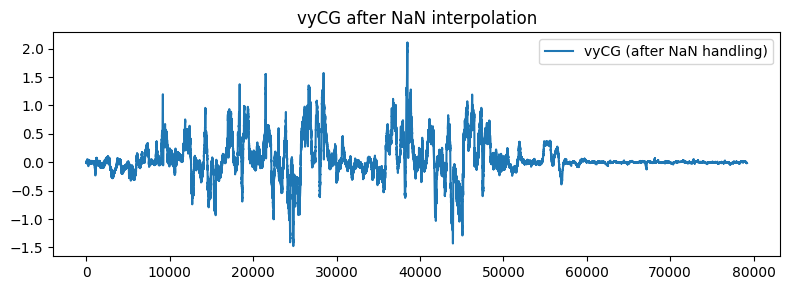

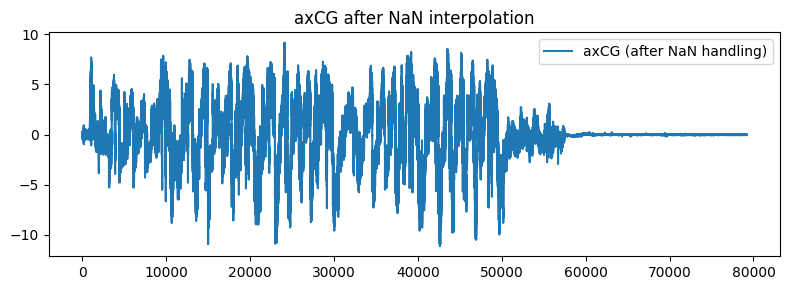

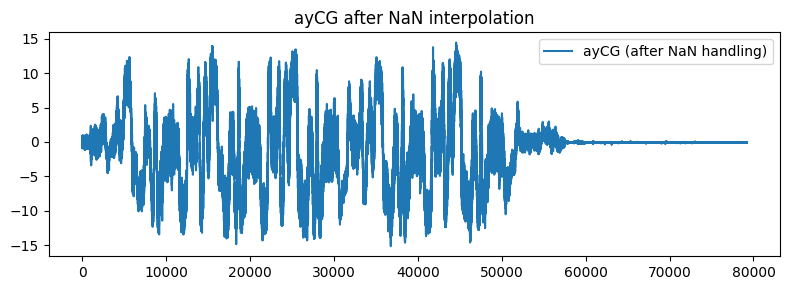

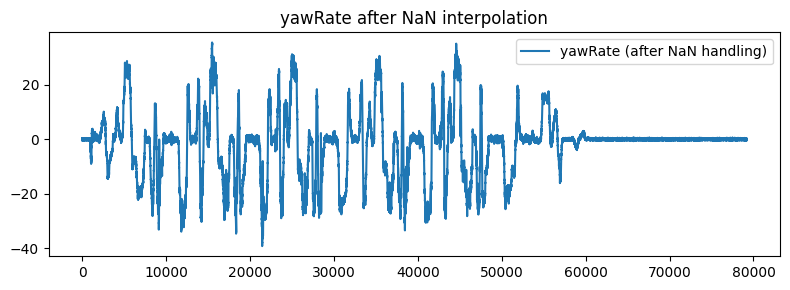

In [17]:
cols_to_plot = ['vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']
for col in cols_to_plot:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f'{col} (after NaN handling)')
    plt.title(f'{col} after NaN interpolation')
    plt.legend()
    plt.tight_layout()
    plt.show()


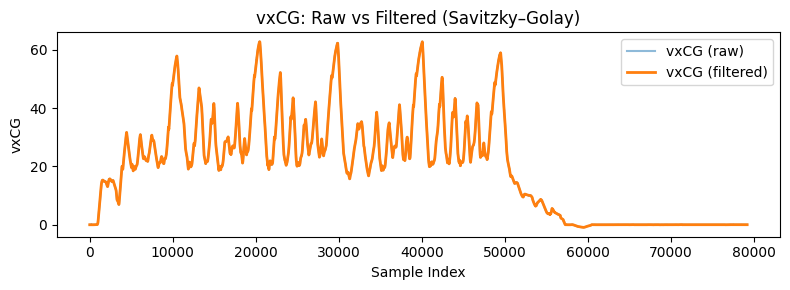

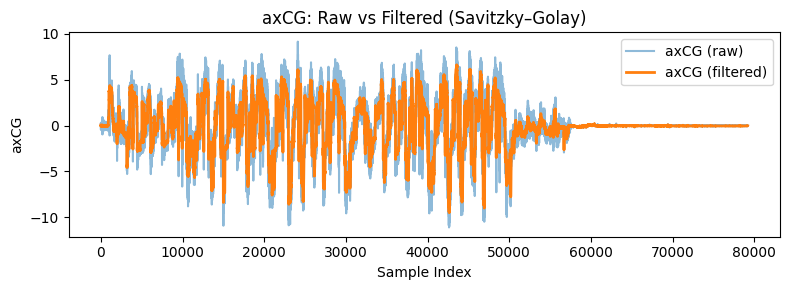

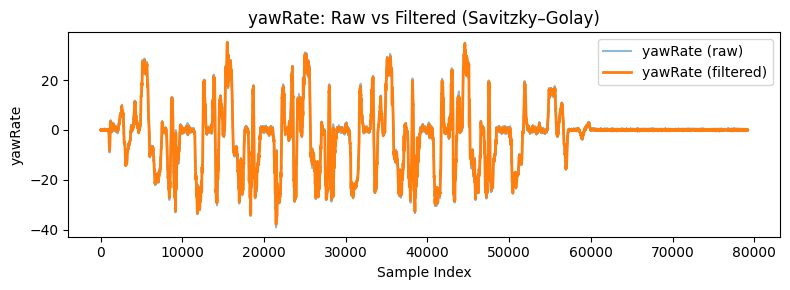

In [ ]:

from scipy.signal import savgol_filter

# Define a helper function for smoothing
def smooth_signal(sig, window=31, poly=2):
   
    if window >= len(sig):
        window = len(sig) - 1 if len(sig) % 2 == 0 else len(sig)
    if window % 2 == 0:
        window += 1
    return savgol_filter(sig, window_length=window, polyorder=poly, mode='nearest')

# Columns to filter (core dynamics)
cols_to_filter = ['vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']

# Apply filter and create new columns with "_filt" suffix
for col in cols_to_filter:
    train_data[col + '_filt'] = smooth_signal(train_data[col].values, window=31, poly=2)

# Quick comparison: plot before vs after for a few signals

for col in ['vxCG', 'axCG', 'yawRate']:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f'{col} (raw)', alpha=0.5)
    plt.plot(train_data[col + "_filt"].values, label=f'{col} (filtered)', linewidth=2)
    plt.title(f"{col}: Raw vs Filtered (Savitzky–Golay)")
    plt.xlabel("Sample Index")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [30]:

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Prepare inputs and targets 
vx = train_data['vxCG_filt'].values
vy = train_data['vyCG_filt'].values
r  = train_data['yawRate_filt'].values
ax = train_data['axCG_filt'].values
ay = train_data['ayCG_filt'].values

# Input at time k : [vx, vy, r, ax, ay]
# Target at time k+1 : [vx_next, vy_next]
X = np.column_stack([vx[:-1], vy[:-1], r[:-1], ax[:-1], ay[:-1]])
Y = np.column_stack([vx[1:], vy[1:]])

print(f"Full dataset -> Inputs: {X.shape}, Targets: {Y.shape}")

# Random 80/20 split ===
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

#  Define PyTorch Dataset class ===
class VehicleDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Create Datasets and DataLoaders ===
train_dataset = VehicleDataset(X_train, Y_train)
test_dataset  = VehicleDataset(X_test,  Y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(" train/test split and DataLoaders ready.")




Full dataset -> Inputs: (79199, 5), Targets: (79199, 2)
Training samples: 63359 | Testing samples: 15840
 train/test split and DataLoaders ready.


In [ ]:
plt.figure(figsize=(6,3))
plt.scatter(range(len(vx)-1), vx[:-1], c='gray', s=5, label='All data')
plt.scatter(range(len(X_train)), X_train[:,0], c='blue', s=5, label='Train')
plt.scatter(range(len(X_test)), X_test[:,0], c='red', s=5, label='Test')
plt.title("Random Train/Test Distribution (approximate)")
plt.legend()
plt.tight_layout()
plt.show()


VehicleNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Epoch [1/50] | Train Loss: 11.587320 | Test Loss: 0.009975
Epoch [2/50] | Train Loss: 0.008371 | Test Loss: 0.006478
Epoch [3/50] | Train Loss: 0.005456 | Test Loss: 0.004253
Epoch [4/50] | Train Loss: 0.003229 | Test Loss: 0.001938
Epoch [5/50] | Train Loss: 0.001487 | Test Loss: 0.000923
Epoch [6/50] | Train Loss: 0.000679 | Test Loss: 0.000435
Epoch [7/50] | Train Loss: 0.000432 | Test Loss: 0.000413
Epoch [8/50] | Train Loss: 0.000375 | Test Loss: 0.000496
Epoch [9/50] | Train Loss: 0.000456 | Test Loss: 0.000242
Epoch [10/50] | Train Loss: 0.000279 | Test Loss: 0.000251
Epoch [11/50] | Train Loss: 0.000401 | Test Loss: 0.000206
Epoch [12/50] | Train Loss: 0.000374 | Test Loss: 0.000181
Epoch [13/50] | Train Loss: 0.000350 | Test Loss: 0.

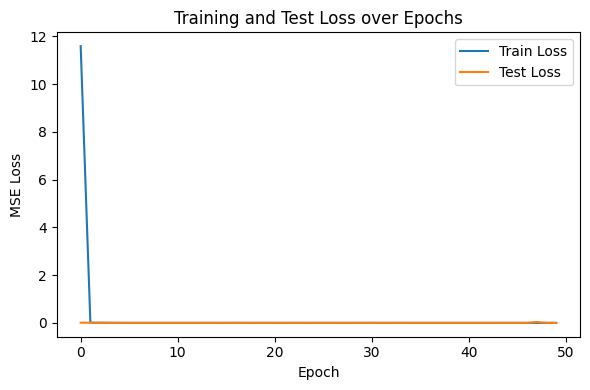

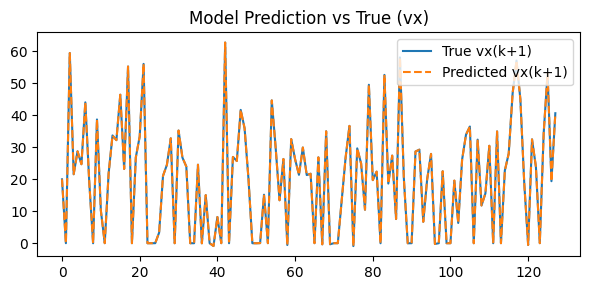

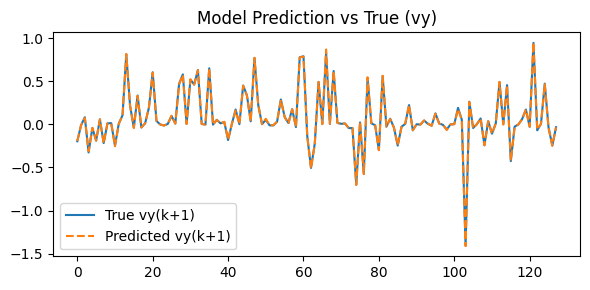

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#  Define the Neural Network Architecture ===
class VehicleNN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64, output_dim=2):
        super(VehicleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = VehicleNN()
print(model)

#  Define Loss Function and Optimizer
criterion = nn.MSELoss()                     # Mean squared error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training Loop
num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            test_loss += loss.item()
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print(" Training complete.")

# ===  Plot Loss Curves ===
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Training and Test Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

#  Evaluate Model on Test Data
model.eval()
with torch.no_grad():
    X_test_sample, Y_test_sample = next(iter(test_loader))
    Y_pred = model(X_test_sample).numpy()
    Y_true = Y_test_sample.numpy()

plt.figure(figsize=(6,3))
plt.plot(Y_true[:200,0], label='True vx(k+1)')
plt.plot(Y_pred[:200,0], label='Predicted vx(k+1)', linestyle='--')
plt.title("Model Prediction vs True (vx)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.plot(Y_true[:200,1], label='True vy(k+1)')
plt.plot(Y_pred[:200,1], label='Predicted vy(k+1)', linestyle='--')
plt.title("Model Prediction vs True (vy)")
plt.legend()
plt.tight_layout()
plt.show()


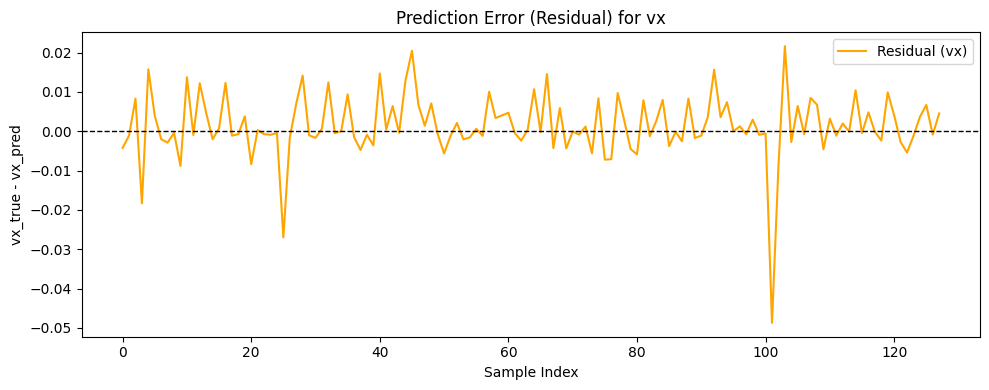

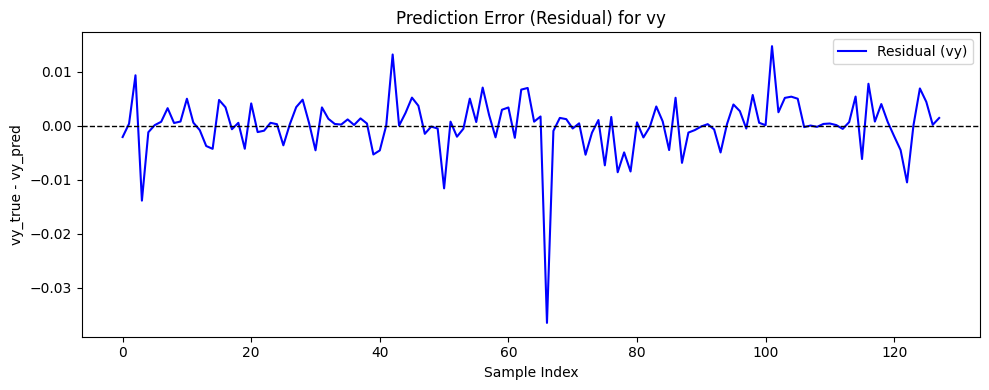

vx Residuals → Mean: 0.001387, Std: 0.008083, RMSE: 0.008201
vy Residuals → Mean: 0.000136, Std: 0.005291, RMSE: 0.005293


In [29]:

import matplotlib.pyplot as plt
import numpy as np

# Compute residuals (difference between true and predicted)
residual_vx = Y_true[:, 0] - Y_pred[:, 0]
residual_vy = Y_true[:, 1] - Y_pred[:, 1]

# Plot residuals over sample index
plt.figure(figsize=(10, 4))
plt.plot(residual_vx, label='Residual (vx)', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vx")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(residual_vy, label='Residual (vy)', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vy")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.tight_layout()
plt.show()


def residual_stats(name, residuals):
    mean_err = np.mean(residuals)
    std_err = np.std(residuals)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

residual_stats("vx", residual_vx)
residual_stats("vy", residual_vy)


___